## Import Libraries

In [1]:
import os

os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"

In [2]:
import numpy as np

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

## Prepare train dataset

In [3]:
import torch
from torchvision import datasets, transforms

class RollRightTransform:
    def __init__(self, shift_pixels):
        self.shift_pixels = shift_pixels

    def __call__(self, tensor):
        # tensor has shape (C, H, W) -> (1, 28, 28) for MNIST
        # dims=2 applies the roll to the Width dimension (horizontal shift)
        return torch.roll(tensor, shifts=self.shift_pixels, dims=2)

In [4]:
# We are shifting the image 5 pixels to the right
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)), 
    RollRightTransform(shift_pixels=14) 
])

# Load the test dataset with the new transform
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform_test
)

## Prepare test dataset

In [5]:
# We are shifting the image 5 pixels to the right
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)), 
    RollRightTransform(shift_pixels=14)
])

# Load the test dataset with the new transform
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

## Data Loaders

In [6]:
# DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=128,
    num_workers=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=128,
    num_workers=4,
    shuffle=True,
    drop_last=False
)

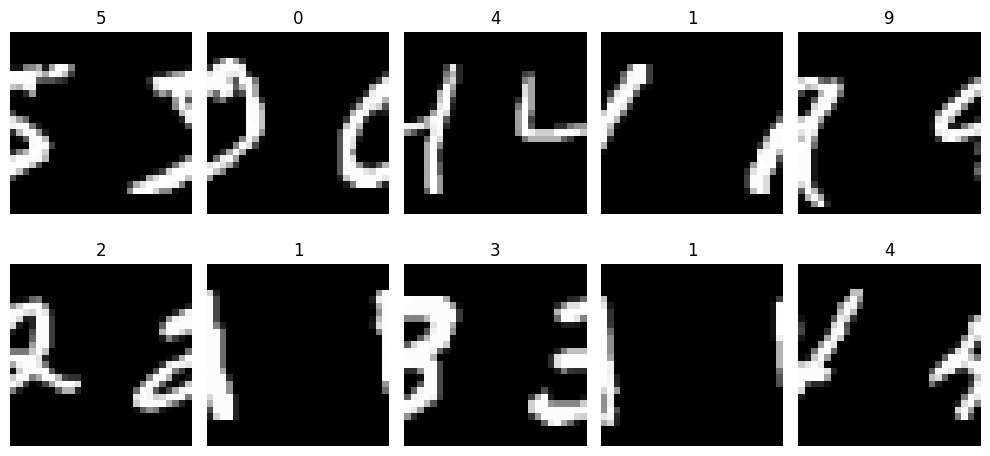

In [7]:
fig, axes = plt.subplots(2,5,figsize=(10,5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    image_np = image.squeeze().numpy()

    ax.imshow(image_np, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Feed Forward Network 

In [8]:
import torch

print(f"¿GPU disponible?: {torch.cuda.is_available()}")
print(f"Nombre de la GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Ninguna'}")

¿GPU disponible?: True
Nombre de la GPU: AMD Radeon RX 6600


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

Entrenando en: cuda


In [10]:
def createTheMNISTNet():

    class mnistNet(nn.Module):
        def __init__(self):
            super().__init__()

            # input layer
            self.input = nn.Linear(784,64) # 784 pixels

            # hidden layer
            self.fc1 = nn.Linear(64,32)
            self.fc2 = nn.Linear(32,32)

            # output layer
            self.output = nn.Linear(32,10)

        def forward(self,x):
            x = x.view(x.shape[0], -1)
            
            x = F.relu( self.input(x) )
            x = F.relu( self.fc1(x) )
            x = F.relu( self.fc2(x) )
            return F.log_softmax( self.output(x), dim=1 )

    net = mnistNet()

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

    return net, lossfun, optimizer

In [11]:
net, lossfun, optimizer = createTheMNISTNet()

X,y = next(iter(train_loader))
yHat = net(X)

print(yHat)

loss = lossfun(yHat, y)
print(' ')
print('Loss:')
print(loss)

tensor([[-2.2642, -2.3944, -2.3596,  ..., -2.4533, -2.1473, -2.1715],
        [-2.2889, -2.3787, -2.3404,  ..., -2.4597, -2.1658, -2.1450],
        [-2.2992, -2.4439, -2.3626,  ..., -2.4597, -2.1376, -2.0875],
        ...,
        [-2.2902, -2.4032, -2.3512,  ..., -2.4600, -2.1441, -2.1513],
        [-2.2916, -2.4252, -2.3733,  ..., -2.4929, -2.1718, -2.0991],
        [-2.2884, -2.4030, -2.3431,  ..., -2.4581, -2.1376, -2.1443]],
       grad_fn=<LogSoftmaxBackward0>)
 
Loss:
tensor(2.2991, grad_fn=<NllLossBackward0>)


## Training

In [12]:
def function2trainTheModel():

    numepochs = 60

    net, lossfun, optimizer = createTheMNISTNet()
    net.to(device)

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        # ===== Train =====
        batchAcc = []
        batchLoss = []
        for X,y in train_loader:

            X, y = X.to(device), y.to(device)
            
            # forward
            yHat = net(X)
            loss = lossfun(yHat, y)

            # back
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # loss
            batchLoss.append( loss.item() )

            # accuracy
            matches = torch.argmax(yHat, axis=1) == y # predictions
            matchesNumeric = matches.float() # to numeric
            accuracyPct = 100*torch.mean(matchesNumeric) # pct of mean
            batchAcc.append( accuracyPct.item() ) # add

        trainAcc.append( np.mean(batchAcc) )

        losses[epochi] = np.mean(batchLoss)

        # ===== Test =====
        X,y = next(iter(test_loader))
        X, y = X.to(device), y.to(device)
        yHat = net(X)

        acc = 100*torch.mean( (torch.argmax(yHat, axis=1)==y).float() )
        testAcc.append( acc.item() )
        
        print(f'Epoch: {epochi} \f trainAcc: {trainAcc[epochi]} \f testAcc: {testAcc[epochi]}')

    return trainAcc, testAcc, losses, net

In [13]:
trainAcc, testAcc, losses, net = function2trainTheModel()

/home/alexpy/Documents/DLNotes/.venv/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:310.)
  return F.linear(input, self.weight, self.bias)


Epoch: 0  trainAcc: 80.9745592948718  testAcc: 92.1875
Epoch: 1  trainAcc: 94.63975694444444  testAcc: 95.3125
Epoch: 2  trainAcc: 96.27069978632478  testAcc: 96.875
Epoch: 3  trainAcc: 97.0786591880342  testAcc: 96.875
Epoch: 4  trainAcc: 97.60283119658119  testAcc: 96.875
Epoch: 5  trainAcc: 97.94170673076923  testAcc: 96.09375
Epoch: 6  trainAcc: 98.17708333333333  testAcc: 97.65625
Epoch: 7  trainAcc: 98.48090277777777  testAcc: 100.0
Epoch: 8  trainAcc: 98.6061030982906  testAcc: 96.09375
Epoch: 9  trainAcc: 98.77637553418803  testAcc: 93.75
Epoch: 10  trainAcc: 98.9433092948718  testAcc: 99.21875
Epoch: 11  trainAcc: 99.05348557692308  testAcc: 96.875
Epoch: 12  trainAcc: 99.19704861111111  testAcc: 98.4375
Epoch: 13  trainAcc: 99.27717681623932  testAcc: 98.4375
Epoch: 14  trainAcc: 99.40237713675214  testAcc: 95.3125
Epoch: 15  trainAcc: 99.45078792735043  testAcc: 96.875
Epoch: 16  trainAcc: 99.49252136752136  testAcc: 98.4375
Epoch: 17  trai

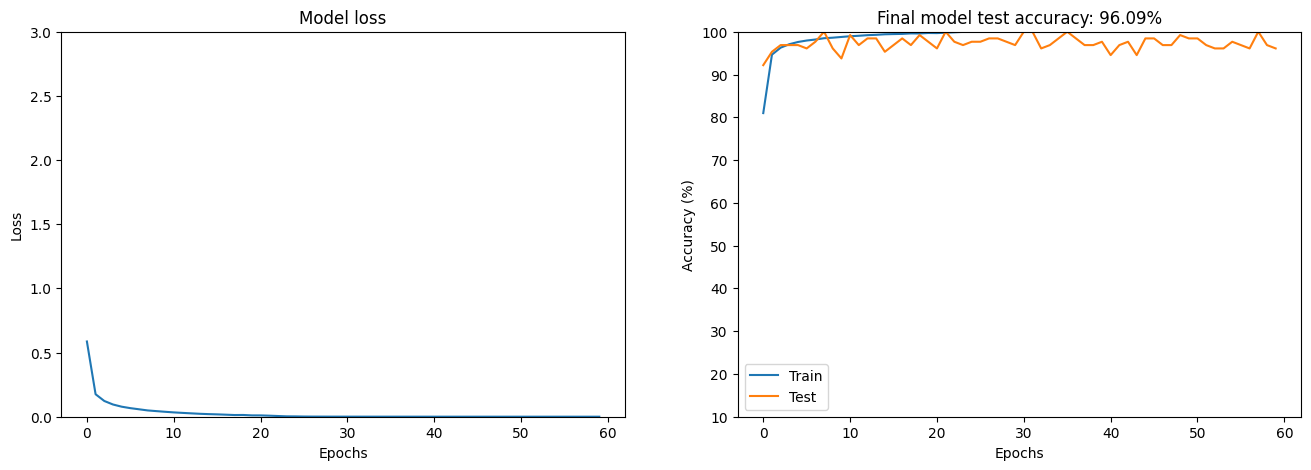

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0,3])
ax[0].set_title('Model loss')

ax[1].plot(trainAcc, label='Train')
ax[1].plot(testAcc, label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_ylim([10,100])
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()


Se encontraron 3 errores en este batch.




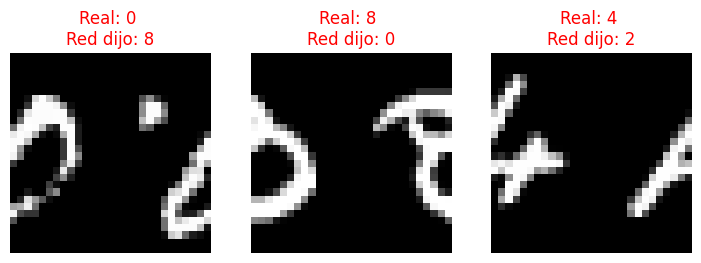

In [15]:
import math
import matplotlib.pyplot as plt
import torch

X, y = next(iter(test_loader))
X, y = X.to(device), y.to(device)

with torch.no_grad():
    predictions = net(X)

predictions = predictions.cpu()
y = y.cpu()
X = X.cpu()

predicted_classes = torch.argmax(predictions, dim=1)
errors = torch.where(predicted_classes != y)[0]

num_errors = len(errors)
print(f'\nSe encontraron {num_errors} errores en este batch.\n\n')

if num_errors > 0:
    max_to_show = min(num_errors, 25) 
    
    cols = 5 
    rows = math.ceil(max_to_show / cols)
    
    fig = plt.figure(figsize=(15, rows * 3))
    
    for i in range(max_to_show):
        error_idx = errors[i]
        true_val = y[error_idx].item()
        guess_val = predicted_classes[error_idx].item()
        
        ax = fig.add_subplot(rows, cols, i + 1)
        
        img_to_show = X[error_idx].view(28, 28)
        ax.imshow(img_to_show, cmap='gray')
        
        ax.set_title(f'Real: {true_val} \nRed dijo: {guess_val}', color='red')
        ax.axis('off') 